### Model Evaluation & Best model selection
* input : `model/train/edge_cctv_v1/weights/best.pt`
* test set: 76 images - never seen during training or validation

In [1]:
import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
import json
import yaml
from IPython.display import display
import mlflow
import random

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [3]:
# Paths 
PROJECT_ROOT = Path.cwd().parent
YOLOV5_DIR = PROJECT_ROOT / 'model' / 'yolov5'
DATA_YAML = PROJECT_ROOT / 'data' / 'data.yaml'
TEST_IMAGES = PROJECT_ROOT / 'data' / 'splits' / 'test' / 'images'
TEST_LABELS = PROJECT_ROOT / 'data' / 'splits' / 'test' / 'labels'

RUN_NAME = 'edge_cctv_v2' # name of the training run
RUN_DIR = PROJECT_ROOT / 'model' / 'train' / RUN_NAME
BEST_PT = RUN_DIR / 'weights' / 'best.pt'
EVAL_DIR = PROJECT_ROOT / 'model' / 'val' / RUN_NAME

# Threshold for model acceptance decision
CONF_THRESHOLD = 0.25 # min conf to count a decision (YOLOv5 default)
IOU_THRESHOLD = 0.45 # IoU for Non-Max Suppression
MAP_TARGET = 0.60 # Min acceptable mAP@50 for deployment

# MLflow
MLFLOW_EXPERIMENT = 'YOLOv5n-CCTV-PersonDetection'

print(f'Best checkpoint : {BEST_PT}')
print(f'Exists : {BEST_PT.exists()}')
print(f'Test images : {len(list(TEST_IMAGES.glob("*.*")))} files')

Best checkpoint : c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\weights\best.pt
Exists : True
Test images : 76 files


#### Eval 1: Run YOLOv5 Evaluation on test set
* use val.py from YOLOv5 repo with the test split


In [5]:
# check if best.pt exists
assert BEST_PT.exists(), f' best.pt not found at {BEST_PT}'

val_cmd = [
    sys.executable, str(YOLOV5_DIR / 'val.py'),
    '--weights', str(BEST_PT),
    '--data', str(DATA_YAML),
    '--img', '640',
    '--conf', str(CONF_THRESHOLD),
    '--iou', str(IOU_THRESHOLD),
    '--task', 'test',
    '--project', str(PROJECT_ROOT / 'model'/ 'val'),
    '--name', RUN_NAME,
    '--exist-ok',
    '--save-txt', # save per-image prediction .txt files
    '--save-conf', # include confidence in saved .txt
    '--verbose',
]

print('Running evaluation on test set ')
print(' '.join(val_cmd))

result = subprocess.run(val_cmd, capture_output=False, cwd=str(YOLOV5_DIR))

if result.returncode == 0:
    print('Evaluation complete')
else:
    print('val.py failed with code ', result.returncode)

Running evaluation on test set 
c:\Users\ASUS\Desktop\EdgeIA_PFE\venv\Scripts\python.exe c:\Users\ASUS\Desktop\EdgeIA_PFE\model\yolov5\val.py --weights c:\Users\ASUS\Desktop\EdgeIA_PFE\model\train\edge_cctv_v2\weights\best.pt --data c:\Users\ASUS\Desktop\EdgeIA_PFE\data\data.yaml --img 640 --conf 0.25 --iou 0.45 --task test --project c:\Users\ASUS\Desktop\EdgeIA_PFE\model\val --name edge_cctv_v2 --exist-ok --save-txt --save-conf --verbose
Evaluation complete


#### Eval 2: Parse & display metrics
* display result from the output folder.

In [28]:
csv_file = RUN_DIR / 'results.csv'
assert csv_file.exists(), f'results.csv not found at {csv_file}'

df_train = pd.read_csv(csv_file)
df_train.columns = df_train.columns.str.strip()

map_col = 'metrics/mAP_0.5'
best_idx = df_train[map_col].idxmax()
best_row = df_train.loc[best_idx]

# metrics summary
metrics = {
    'Epoch (best)': int(best_idx),
    'Precision': round(float(best_row.get('metrics/precision', 0)), 4),
    'Recall': round(float(best_row.get('metrics/recall', 0)), 4),
    'mAP@0.5': round(float(best_row.get('metrics/mAP_0.5', 0)), 4),
    'mAP@0.5:0.95': round(float(best_row.get('metrics/mAP_0.5:0.95', 0)), 4),
    'Val box loss': round(float(best_row.get('val/box_loss', 0)), 4),
    'Val obj loss': round(float(best_row.get('val/obj_loss', 0)), 4),
}

# F1 score from the precision and recall

p = metrics['Precision']
r = metrics['Recall']
f1 = round(2 * p * r / (p + r + 1e-9), 4)
metrics['F1 Score'] = f1

print('='*50)
print('EVALUATION METRICS (best.pt on validation set)')
print('='*50)
for k, v in metrics.items():
    print(f'  {k:<22}: {v}')
print('='*50)

EVALUATION METRICS (best.pt on validation set)
  Epoch (best)          : 36
  Precision             : 0.8756
  Recall                : 0.8736
  mAP@0.5               : 0.937
  mAP@0.5:0.95          : 0.6677
  Val box loss          : 0.0241
  Val obj loss          : 0.0539
  F1 Score              : 0.8746


#### Eval 3: Metrics Visualisation
* Visual summary of precision, recall, F1, and mAP

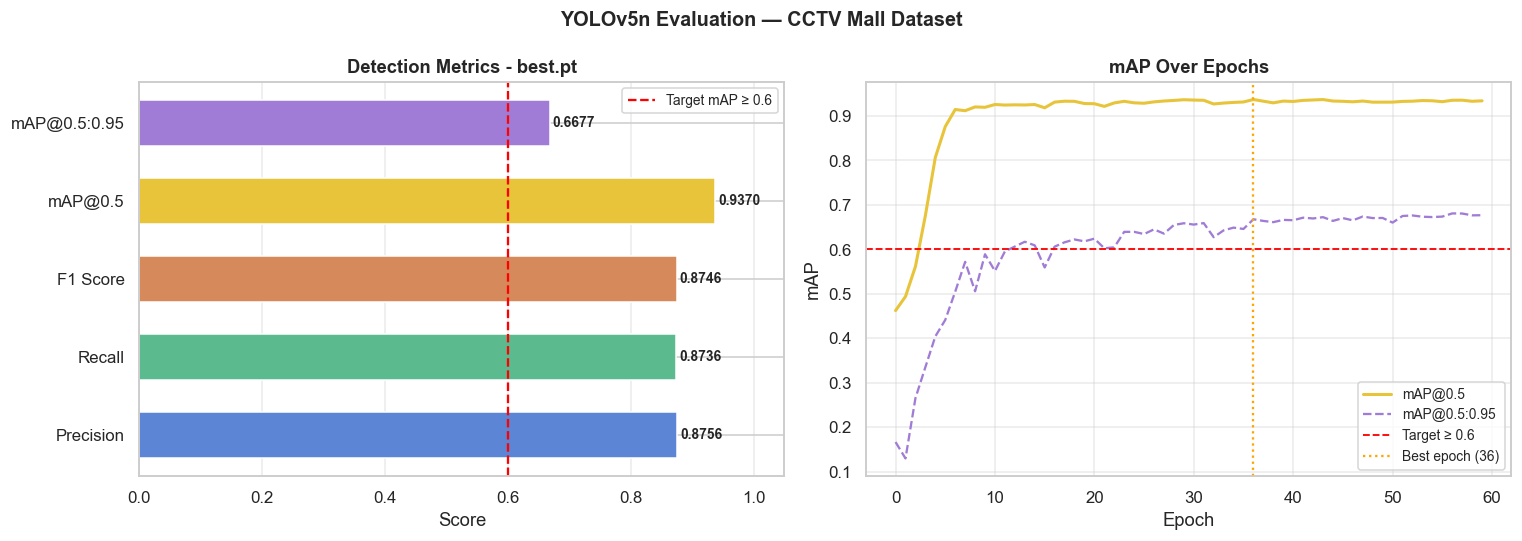

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - core metrics
ax1 = axes[0]
metric_names  = ['Precision', 'Recall', 'F1 Score', 'mAP@0.5', 'mAP@0.5:0.95']
metric_values = [metrics[m] for m in metric_names]
colors = ['#5c85d6', '#5cba8f', '#d68a5c', '#e8c43a', '#a07cd6']

bars = ax1.barh(metric_names, metric_values, color=colors, edgecolor='white', height=0.6)
ax1.axvline(MAP_TARGET, color='red', linestyle='--', linewidth=1.5, label=f'Target mAP ≥ {MAP_TARGET}')

for bar, val in zip(bars, metric_values):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax1.set_xlim(0, 1.05)
ax1.set_xlabel('Score')
ax1.set_title('Detection Metrics - best.pt', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, axis='x', alpha=0.4)

# Line chart - mAP over training epochs 
ax2 = axes[1]
if map_col in df_train.columns:
    ax2.plot(df_train.index, df_train[map_col], color='#e8c43a', linewidth=2, label='mAP@0.5')
    if 'metrics/mAP_0.5:0.95' in df_train.columns:
        ax2.plot(df_train.index, df_train['metrics/mAP_0.5:0.95'],
                 color='#a07cd6', linewidth=1.5, linestyle='--', label='mAP@0.5:0.95')
    ax2.axhline(MAP_TARGET, color='red', linestyle='--', linewidth=1.2, label=f'Target ≥ {MAP_TARGET}')
    ax2.axvline(best_idx, color='orange', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_idx})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('mAP')
    ax2.set_title('mAP Over Epochs', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.4)

plt.suptitle('YOLOv5n Evaluation — CCTV Mall Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'eval_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

#### Eval 4: Precision-Recall Curve

*  The PR curve shows the trade-off between precision and recall at different confidence thresholds. 

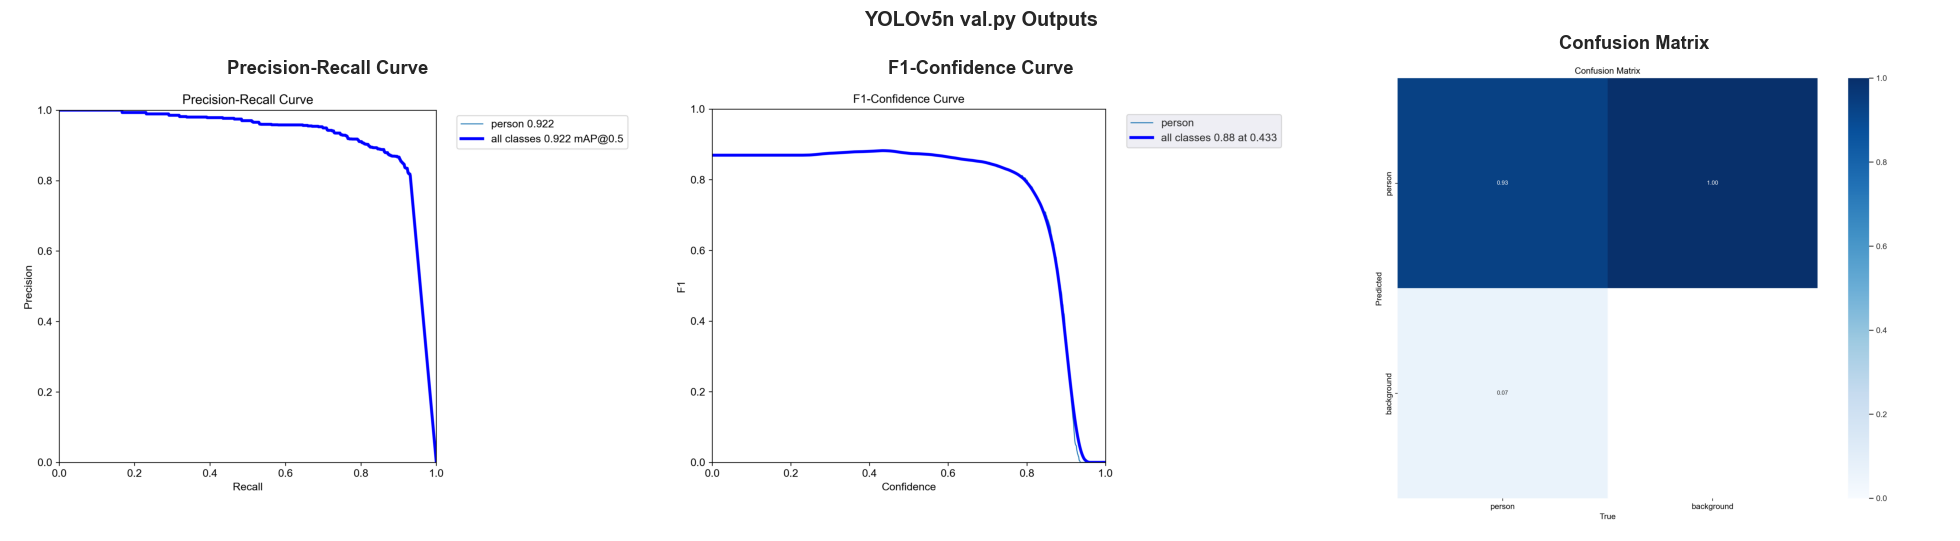

In [ ]:
pr_curve = EVAL_DIR / 'PR_curve.png'
confusion = EVAL_DIR / 'confusion_matrix.png'
f1_curve  = EVAL_DIR / 'F1_curve.png'

# Display val.py generated plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def show_yolov5_plot(ax, path, title):
    """Show a YOLOv5-generated plot image, or a placeholder if missing."""
    if path.exists():
        img = Image.open(path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontweight='bold')
    else:
        ax.text(0.5, 0.5,
                f'{title}\n\nFile not found:\n{path.name}\n\nRun val.py first.',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=10, color='gray')
        ax.set_title(title, fontweight='bold')
        ax.axis('off')

show_yolov5_plot(axes[0], pr_curve, 'Precision-Recall Curve')
show_yolov5_plot(axes[1], f1_curve, 'F1-Confidence Curve')
show_yolov5_plot(axes[2], confusion, 'Confusion Matrix')

plt.suptitle('YOLOv5n val.py Outputs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' /'eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### Eval 5: Visual spot-check -- detections on test images
* Draw predicted bbox on a sample of 12 test images
* We use the YOLOv5 `detect.py` script, then display the results.

In [16]:
DETECT_OUT = PROJECT_ROOT / 'model' / 'detect' / 'test_spotcheck'

detect_cmd = [
    sys.executable, str(YOLOV5_DIR / 'detect.py'),
    '--weights', str(BEST_PT),
    '--source', str(TEST_IMAGES),
    '--img', '640',
    '--conf', str(CONF_THRESHOLD),
    '--iou', str(IOU_THRESHOLD),
    '--project', str(PROJECT_ROOT / 'model' / 'detect'),
    '--name', 'test_spotcheck',
    '--exist-ok',
    '--save-txt',
    '--save-conf',
]

print('Running detect.py on test images...')
result = subprocess.run(detect_cmd, cwd=str(YOLOV5_DIR))

if result.returncode == 0:
    print(f'\n Detections saved to: {DETECT_OUT}')
else:
    print(f'\n detect.py failed (code {result.returncode})')

Running detect.py on test images...

 Detections saved to: c:\Users\ASUS\Desktop\EdgeIA_PFE\model\detect\test_spotcheck


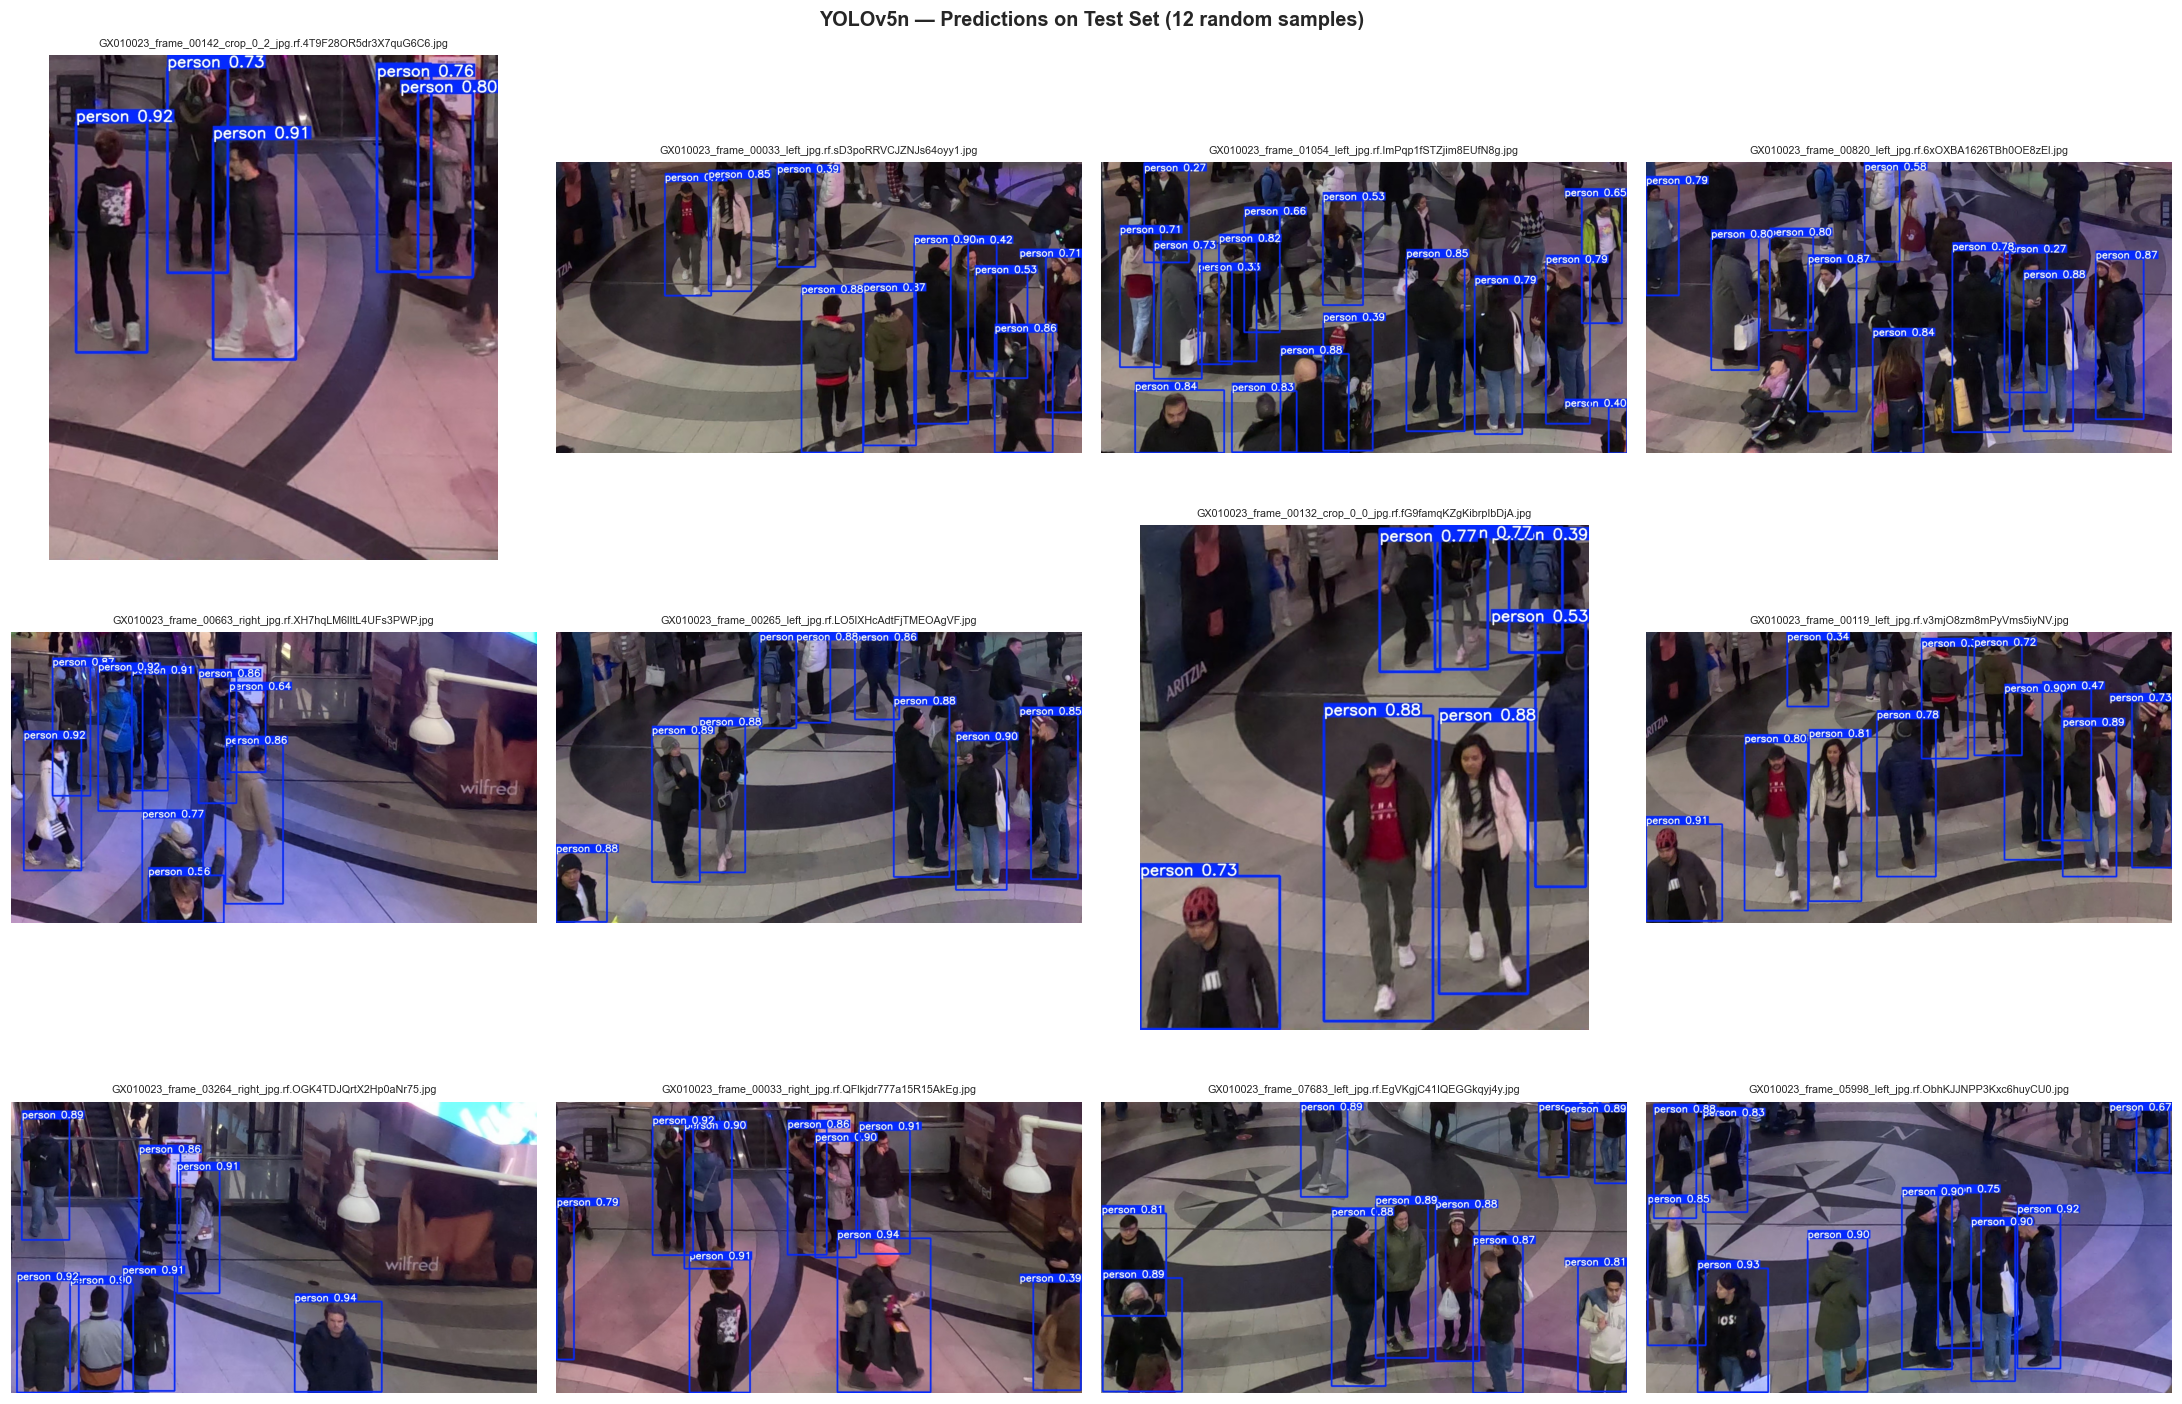


Displaying 12 out of 76 predictions.


In [ ]:
# reproducible sample
random.seed(42)

if DETECT_OUT.exists():
    all_preds = sorted(list(DETECT_OUT.glob('*.jpg')) + list(DETECT_OUT.glob('*.png')))
    sample = random.sample(all_preds, min(12, len(all_preds)))

    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    axes = axes.flatten()

    for i, img_path in enumerate(sample):
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(img_path.name, fontsize=7)

    # Hide unused subplots
    for j in range(len(sample), len(axes)):
        axes[j].axis('off')

    plt.suptitle('YOLOv5n — Predictions on Test Set (12 random samples)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'plots' / 'eval_spotcheck.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nDisplaying {len(sample)} out of {len(all_preds)} predictions.')
else:
    print(f' Detection output folder not found: {DETECT_OUT}')

#### Eval 6: False Positives & False Negative

* Compare model predictions with the ground truth labels to identify where the model fails.

In [19]:
def compute_iou(boxA, boxB):
    """
    Compute IoU between two YOLO-format boxes (cx, cy, w, h normalised).
    Converts to corner format for intersection calculation.
    """
    def to_corners(b):
        cx, cy, w, h = b
        return cx - w/2, cy - h/2, cx + w/2, cy + h/2

    ax1, ay1, ax2, ay2 = to_corners(boxA)
    bx1, by1, bx2, by2 = to_corners(boxB)

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    areaA = (ax2 - ax1) * (ay2 - ay1)
    areaB = (bx2 - bx1) * (by2 - by1)
    union = areaA + areaB - inter + 1e-9
    return inter / union


def read_label_file(path):
    """Read a YOLO .txt label file → list of (class, cx, cy, w, h)."""
    if not path.exists():
        return []
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                rows.append([float(x) for x in parts])
    return rows


# Match predictions to ground truth
pred_label_dir = DETECT_OUT / 'labels'
IOU_MATCH = 0.5  # IoU threshold to count a detection as TP

tp_total = fp_total = fn_total = 0
per_image_results = []

test_imgs = sorted(TEST_IMAGES.glob('*.*'))

for img_path in test_imgs:
    gt_path   = TEST_LABELS  / (img_path.stem + '.txt')
    pred_path = pred_label_dir / (img_path.stem + '.txt') if pred_label_dir.exists() else None

    gts   = read_label_file(gt_path)
    preds = read_label_file(pred_path) if pred_path else []

    matched_gt = set()
    tp = fp = 0

    for pred in preds:
        pred_box = pred[1:5]  # cx cy w h
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gts):
            if j in matched_gt:
                continue
            iou = compute_iou(pred_box, gt[1:5])
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= IOU_MATCH and best_j >= 0:
            tp += 1
            matched_gt.add(best_j)
        else:
            fp += 1

    fn = len(gts) - len(matched_gt)
    tp_total += tp
    fp_total += fp
    fn_total += fn
    per_image_results.append({'image': img_path.name, 'tp': tp, 'fp': fp, 'fn': fn, 'gt_count': len(gts), 'pred_count': len(preds)})

precision_manual = tp_total / (tp_total + fp_total + 1e-9)
recall_manual = tp_total / (tp_total + fn_total + 1e-9)
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual + 1e-9)

print('Error Analysis (IoU match threshold = 0.5)')
print(f'True Positives  (TP): {tp_total}')
print(f'False Positives (FP): {fp_total}  - detections with no matching GT box')
print(f'False Negatives (FN): {fn_total}  - GT boxes not detected (missed persons)')
print(f'Precision : {precision_manual:.4f}')
print(f'Recall : {recall_manual:.4f}')
print(f'F1 Score : {f1_manual:.4f}')

Error Analysis (IoU match threshold = 0.5)
True Positives  (TP): 589
False Positives (FP): 182  - detections with no matching GT box
False Negatives (FN): 104  - GT boxes not detected (missed persons)
Precision : 0.7639
Recall : 0.8499
F1 Score : 0.8046


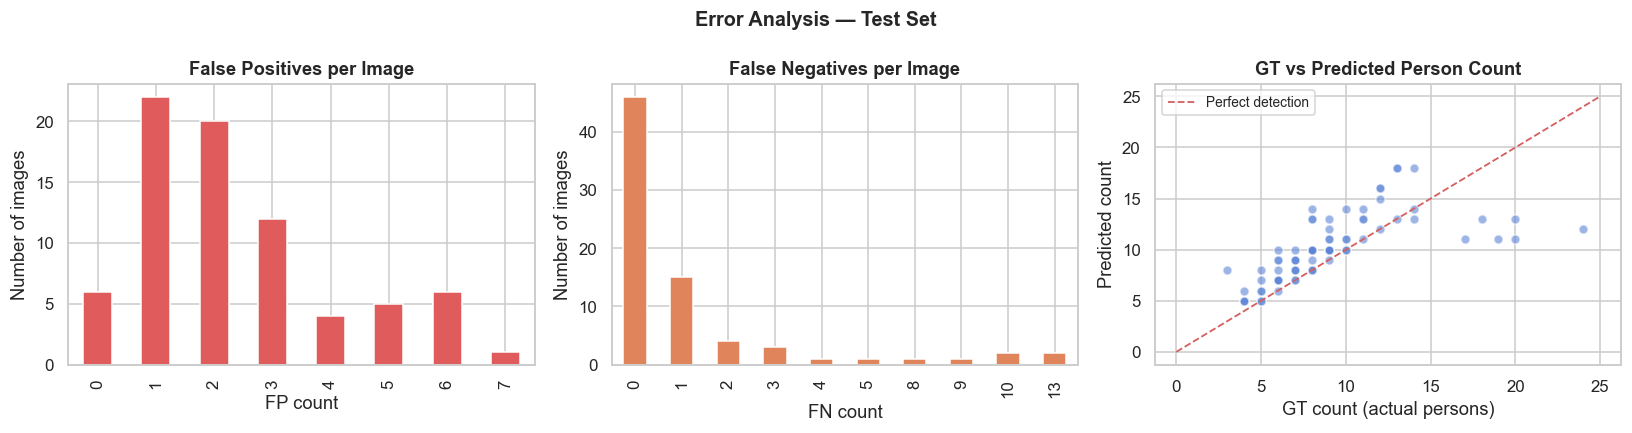

In [ ]:
# Distribution of FP and FN across test images 
df_err = pd.DataFrame(per_image_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_err['fp'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='#e05c5c', edgecolor='white')
axes[0].set_title('False Positives per Image', fontweight='bold')
axes[0].set_xlabel('FP count')
axes[0].set_ylabel('Number of images')

df_err['fn'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='#e0845c', edgecolor='white')
axes[1].set_title('False Negatives per Image', fontweight='bold')
axes[1].set_xlabel('FN count')
axes[1].set_ylabel('Number of images')

axes[2].scatter(df_err['gt_count'], df_err['pred_count'],
                alpha=0.6, color='#5c85d6', edgecolors='white')
max_val = max(df_err[['gt_count', 'pred_count']].max()) + 1
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect detection')
axes[2].set_xlabel('GT count (actual persons)')
axes[2].set_ylabel('Predicted count')
axes[2].set_title('GT vs Predicted Person Count', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Error Analysis — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'eval_errors.png', dpi=150, bbox_inches='tight')
plt.show()

#### Eval 7: Log Evaluation to MLflow
* Log the evaluation results

In [21]:


map_val  = metrics['mAP@0.5']
prec_val = metrics['Precision']
rec_val  = metrics['Recall']
f1_val   = metrics['F1 Score']

CRITERIA = {
    'mAP@0.5 ≥ 0.60':   (map_val  >= MAP_TARGET),
    'Recall  ≥ 0.50':    (rec_val  >= 0.50),
    'Precision ≥ 0.50':  (prec_val >= 0.50),
}

all_pass = all(CRITERIA.values())

mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name=f'{RUN_NAME}_evaluation') as run:

    mlflow.log_params({
        'eval_split': 'test',
        'conf_threshold': CONF_THRESHOLD,
        'iou_threshold': IOU_THRESHOLD,
        'iou_match': 0.5,
        'checkpoint': 'best.pt',
    })

    mlflow.log_metrics({
        'test_mAP_0.5': map_val,
        'test_precision': prec_val,
        'test_recall': rec_val,
        'test_f1': f1_val,
        'test_TP': tp_total,
        'test_FP': fp_total,
        'test_FN': fn_total,
        'model_accepted': int(all_pass),
    })

    # Log evaluation images as artifacts
    for img_name in ['eval_metrics.png', 'eval_curves.png', 'eval_errors.png', 'eval_spotcheck.png']:
        p = PROJECT_ROOT / img_name
        if p.exists():
            mlflow.log_artifact(str(p), artifact_path='evaluation')

    print(f'Evaluation logged to MLflow. Run ID: {run.info.run_id}')

Evaluation logged to MLflow. Run ID: c4ef68835e1f4c749b6de802af9b64ee
